In [12]:
import os, glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split #splits data for training and testing 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import Callback,EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import  classification_report

In [13]:
file_path = 'dataset_blood_group'

In [14]:
name_class = os.listdir(file_path)
name_class

['A+', 'AB+', 'B-', 'AB-', 'O+', 'O-', 'A-', 'B+']

In [15]:
filepaths = list(glob.glob(file_path+'/**/*.*'))

In [16]:
filepaths[-6:-1]

['dataset_blood_group/B+/cluster_2_1654.BMP',
 'dataset_blood_group/B+/cluster_2_1617.BMP',
 'dataset_blood_group/B+/cluster_2_4800.BMP',
 'dataset_blood_group/B+/cluster_2_1882.BMP',
 'dataset_blood_group/B+/cluster_2_1462.BMP']

In [17]:
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))
labels

['A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',
 'A+',

In [18]:

filepath = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')
data = pd.concat([filepath, labels], axis=1)
data = data.sample(frac=1).reset_index(drop=True)
data.head(5)


,Filepath,Label
0,dataset_blood_group/O+/cluster_6_2431.BMP,O+
1,dataset_blood_group/A-/cluster_1_711.BMP,A-
2,dataset_blood_group/B-/cluster_3_255.BMP,B-
3,dataset_blood_group/A+/cluster_0_4018.BMP,A+
4,dataset_blood_group/O-/cluster_7_863.BMP,O-


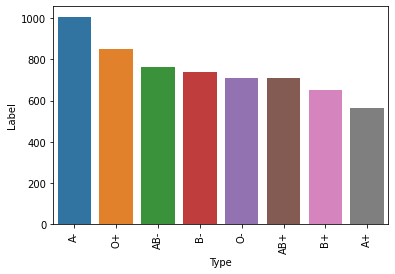

In [19]:
counts = data.Label.value_counts()
sns.barplot(x=counts.index, y=counts)
plt.xlabel('Type')
plt.xticks(rotation=90);

In [20]:
train, test = train_test_split(data, test_size=0.20, random_state=42)

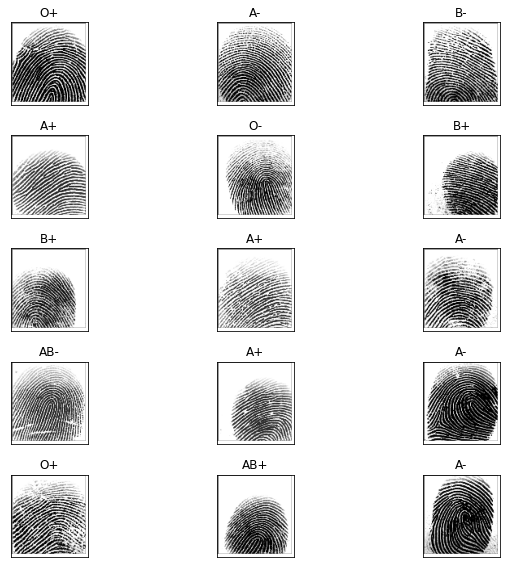

In [21]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(10,8), subplot_kw={'xticks':[],'yticks':[]})
for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(data.Filepath[i]))
    ax.set_title(data.Label[i])
plt.tight_layout()
plt.show()

In [22]:
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [23]:
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train,
    x_col='Filepath',
    y_col='Label',
    target_size=(256,256),
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_gen = train_datagen.flow_from_dataframe(
    dataframe=test,
    x_col='Filepath',
    y_col='Label',
    target_size=(256,256),
    class_mode='categorical',
    batch_size=32,
    shuffle=False,
    seed=42
)
test_gen = test_datagen.flow_from_dataframe(
    dataframe=test,
    x_col='Filepath',
    y_col='Label',
    target_size=(256,256),
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 4500 validated image filenames belonging to 8 classes.
Found 1500 validated image filenames belonging to 8 classes.
Found 1500 validated image filenames belonging to 8 classes.


In [24]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

pretrained_model = VGG16(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

pretrained_model.trainable = False

inputs = pretrained_model.input

x = Dense(128, activation='relu')(pretrained_model.output)
x = Dense(128, activation='relu')(x)

outputs = Dense(8, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)


2023-09-11 12:40:55.473071: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2023-09-11 12:40:55.474224: W tensorflow/stream_executor/cuda/cuda_driver.cc:326] failed call to cuInit: UNKNOWN ERROR (303)
2023-09-11 12:40:55.475978: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (admin1-HP-EliteBook-840-G1): /proc/driver/nvidia/version does not exist
2023-09-11 12:40:55.478284: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [26]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=10
)

Epoch 1/3
141/141 [==============================] - 1149s 8s/step - loss: 0.7907 - accuracy: 0.7007 - val_loss: 0.7306 - val_accuracy: 0.7267
Epoch 2/3
141/141 [==============================] - 1145s 8s/step - loss: 0.6405 - accuracy: 0.7487 - val_loss: 0.7315 - val_accuracy: 0.7273
Epoch 3/3
141/141 [==============================] - 2016s 14s/step - loss: 0.5522 - accuracy: 0.7800 - val_loss: 0.6221 - val_accuracy: 0.7527


In [30]:
model.save("model_blood_group_detection_vgg16.h5")  

/home/admin1/.local/lib/python3.7/site-packages/tensorflow/python/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


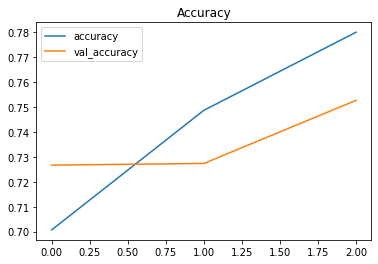

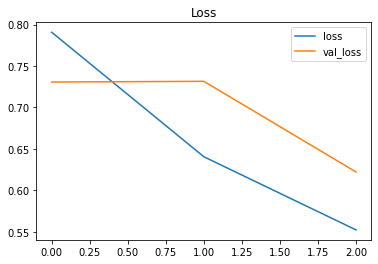

In [31]:
pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot()
plt.title("Accuracy")
plt.show()

pd.DataFrame(history.history)[['loss','val_loss']].plot()
plt.title("Loss")
plt.show()

In [32]:
results = model.evaluate(test_gen, verbose=0)

print("    Test Loss: {:.5f}".format(results[0]))
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

    Test Loss: 0.62211
Test Accuracy: 75.27%


In [33]:
# Predict the label of the test_gen
pred = model.predict(test_gen)
pred = np.argmax(pred,axis=1)

# Map the label
labels = (train_gen.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred = [labels[k] for k in pred]

In [34]:
y_test = list(test.Label)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

          A+       0.63      0.86      0.73       138
          A-       0.76      0.69      0.73       224
         AB+       0.77      0.81      0.79       181
         AB-       0.85      0.67      0.75       218
          B+       0.78      0.74      0.76       163
          B-       0.86      0.88      0.87       185
          O+       0.68      0.72      0.70       210
          O-       0.71      0.71      0.71       181

    accuracy                           0.75      1500
   macro avg       0.76      0.76      0.75      1500
weighted avg       0.76      0.75      0.75      1500



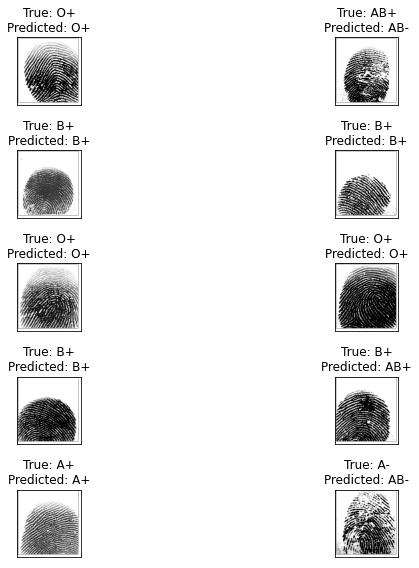

In [35]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 8),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(test.Filepath.iloc[i]))
    ax.set_title(f"True: {test.Label.iloc[i]}\nPredicted: {pred[i]}")
plt.tight_layout()
plt.show()

In [38]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import preprocess_input

img_path = 'cluster_0_303.BMP'

img = image.load_img(img_path, target_size=(256,256))
x = image.img_to_array(img)

x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
result = model.predict(x)
print((result*100).astype('int'))


[[98  0  0  0  0  0  0  0]]
